In [ ]:
import pandas as pd
import numpy as np
nif=pd.read_csv(r"/NIFTY 50-9-02-2023-to-9-02-2024.csv")
nif = pd.DataFrame(nif)
print(nif.shape[0] , "Datapoints are being considered for the study of this particular analysis")
print("\nA GLANCE AT THE DATA \n")
nif['Date ']=pd.to_datetime(nif['Date '])
nif.head()

248 Datapoints are being considered for the study of this particular analysis

A GLANCE AT THE DATA 



,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,2023-02-09,17885.50,17916.90,17779.80,17893.45,260854055,21529.97
1,2023-02-10,17847.55,17876.95,17801.00,17856.50,231991834,17063.99
2,2023-02-13,17859.10,17880.70,17719.75,17770.90,231276483,17406.31
3,2023-02-14,17840.35,17954.55,17800.05,17929.85,244512944,20579.80
4,2023-02-15,17896.60,18034.10,17853.80,18015.85,229273800,21457.34


In [ ]:
nif.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             248 non-null    datetime64[ns]
 1   Open             248 non-null    float64       
 2   High             248 non-null    float64       
 3   Low              248 non-null    float64       
 4   Close            248 non-null    float64       
 5   Shares Traded    248 non-null    int64         
 6   Turnover (₹ Cr)  248 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 13.7 KB


In [ ]:
niftyit=pd.read_csv(r"/NIFTY IT_Historical_PR_01012022to09022024.csv")
print("Number of datapoints used for this analysis are", niftyit.shape[0])
print("\nA GLANCE AT THE DATA \n")
niftyit['Date']=pd.to_datetime(niftyit['Date'])
niftyit.head()

Number of datapoints used for this analysis are 523

A GLANCE AT THE DATA 



,Index Name,Date,Open,High,Low,Close
0,NIFTY IT,2024-02-09,37891.50,38082.05,37443.75,37699.25
1,NIFTY IT,2024-02-08,37893.45,38101.50,37625.75,37851.60
2,NIFTY IT,2024-02-07,38345.40,38373.45,37734.55,37767.75
3,NIFTY IT,2024-02-06,37267.15,38286.00,37161.60,38246.30
4,NIFTY IT,2024-02-05,37441.00,37574.45,37097.95,37162.15


In [ ]:
niftyit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 523 entries, 0 to 522
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Index Name  523 non-null    object        
 1   Date        523 non-null    datetime64[ns]
 2   Open        523 non-null    float64       
 3   High        523 non-null    float64       
 4   Low         523 non-null    float64       
 5   Close       523 non-null    float64       
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 24.6+ KB


In [ ]:
nif.isnull().sum()

Date               0
Open               0
High               0
Low                0
Close              0
Shares Traded      0
Turnover (₹ Cr)    0
dtype: int64

In [ ]:
niftyit=niftyit.drop("Index Name", axis=1)
niftyit.tail()

,Date,Open,High,Low,Close
518,2022-01-07,38140.15,38394.80,38003.15,38139.85
519,2022-01-06,38181.35,38206.60,37757.20,38009.00
520,2022-01-05,39261.55,39293.15,38409.25,38609.15
521,2022-01-04,39243.50,39446.70,38828.60,39370.70
522,2022-01-03,38752.60,39286.35,38752.55,39123.80


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

In [ ]:
#specifing the size of figure
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=nif['Date '],
    y=nif['High '],
    name='High Price',
    line=dict(color='blue'),
    opacity=0.8
))
fig.add_trace(go.Scatter(
    x=nif['Date '],
    y=nif['Low '],
    name='Low Price',
    line=dict(color='red'),
    opacity=0.8
))
fig.update_layout(
    title="NIFTY High Prices V/S Low Prices Over Time",
    yaxis_title="Value",
    showlegend=True,
    plot_bgcolor='lightcyan'
)
fig.show()

In [ ]:
base = alt.Chart(nif).transform_calculate(
legend1="'Close prices of stocks'",
legend2="'Open price of stock'",
)
scale = alt.Scale(domain=["Close prices of stocks", "Open price of stock"], range=['green', 'orange', ])

line1 = base.mark_line(color='green').encode(
x = 'Date :T',
y = 'Close :Q',
color=alt.Color('legend1:N', scale=scale, title=''),
)

line2 = base.mark_line(color='orange').encode(
x = 'Date :T',
y = 'Open :Q',
color=alt.Color('legend2:N', scale=scale, title='')
)
text = alt.Chart(nif).mark_text(
    align='left',
    baseline='middle',
    dx=3
)
(line1 + line2 + text).properties(
    title={"text":['Timeseries Plot of NIFTY Close and Open Price of Stock Over Year'],
           "fontSize":20,
           "fontWeight": 'bold',
           },
    height=500, width=600
).interactive()

alt.LayerChart(...)

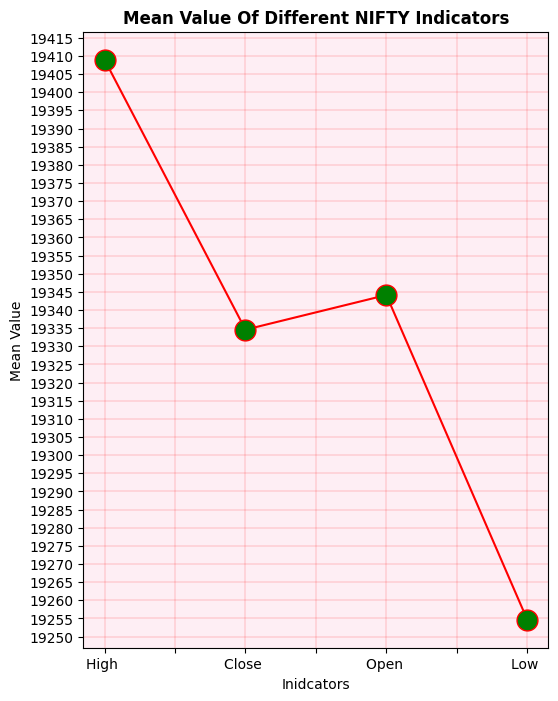

,0
High,19408.954234
Close,19334.569153
Open,19344.116532
Low,19254.652621


In [ ]:
plt.rcParams['figure.figsize']=(6,8)
ax=plt.axes()
ax.set_facecolor("#feeef4")
mean=nif[['High ', 'Close ', 'Open ', 'Low ']].mean()
mean.plot(color="red" ,marker="o" , markersize=15, markerfacecolor="green")
plt.grid(True, alpha= 0.5, color="red", linewidth=0.3)
plt.gca().yaxis.set_major_locator(MultipleLocator(5))
plt.xlabel("Inidcators")
plt.ylabel("Mean Value")
plt.title("Mean Value Of Different NIFTY Indicators",fontweight="semibold")
plt.show()
mean.to_frame()

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=nif['Date '],
    y=nif['Low '],
    name='Low Price',
    line=dict(color='#dc13ff'),
    opacity=0.8
))
fig.add_trace(go.Scatter(
    x=nif['Date '],
    y=nif['High '],
    name='High Price',
    line=dict(color='blue'),
    opacity=0.8
))
fig.update_layout(
    title="DATES WITH STEEP FALL IN MARKET VALUE",
    yaxis_title="Value",
    showlegend=True,
    plot_bgcolor='#fef5b6'
)

fig.add_shape(
    type="line",
    x0='2023-03-31',
    y0=16000,
    x1='2023-03-31',
    y1=22500,
    line=dict(
        color="green",
        width=2,
        dash="solid",
    )
)
fig.add_shape(
    type="line",
    x0='2023-10-26',
    y0=16000,
    x1='2023-10-26',
    y1=22500,

    line=dict(
        color="RED",
        width=2,
        dash="dot",
    )
)
fig.add_annotation(
    x='2023-03-31',
    y=20000,
    text="FINANCIAL YEAR END(31-03-2023)",
    showarrow=True,
    arrowhead=2,
    ax=120,
    ay=20
)
fig.add_annotation(
    x='2023-10-26',
    y=20000,
    text="DUSSHERA END(26-10-2023)",
    showarrow=True,
    arrowhead=6,
    ax=120,
    ay=20
)
fig.show()

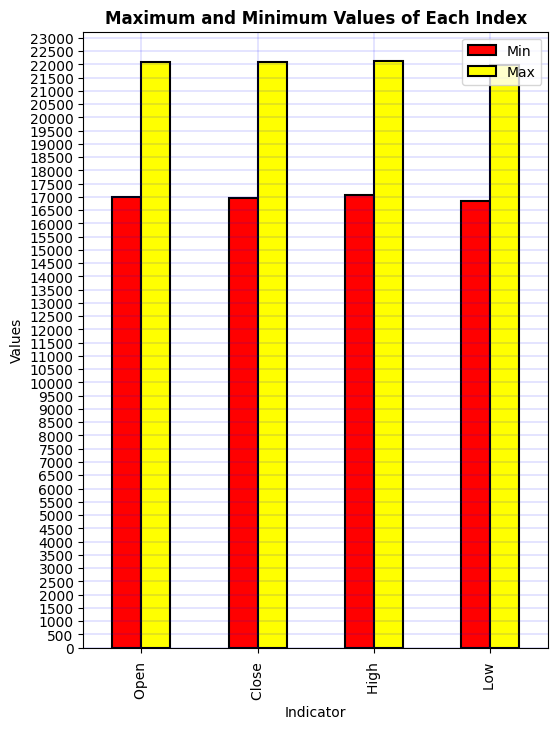

,Min,Max
Open,16977.30,22080.50
Close,16945.05,22097.45
High,17061.75,22126.80
Low,16828.35,21969.80


In [ ]:
max_values = nif[['Open ', 'Close ', 'High ', 'Low ']].max()
min_values = nif[['Open ', 'Close ', 'High ', 'Low ']].min()
bar_df = pd.DataFrame({'Min': min_values, 'Max': max_values})
bar_df.plot(kind='bar', color=['red','yellow'], edgecolor=['black','black'], linewidth=1.5)
plt.grid(True, alpha= 0.5, color="blue", linewidth=0.3)
plt.gca().yaxis.set_major_locator(MultipleLocator(500))
plt.title('Maximum and Minimum Values of Each Index', fontweight="semibold")
plt.xlabel('Indicator')
plt.ylabel('Values')
plt.show()
bar_df=pd.DataFrame(bar_df)
bar_df

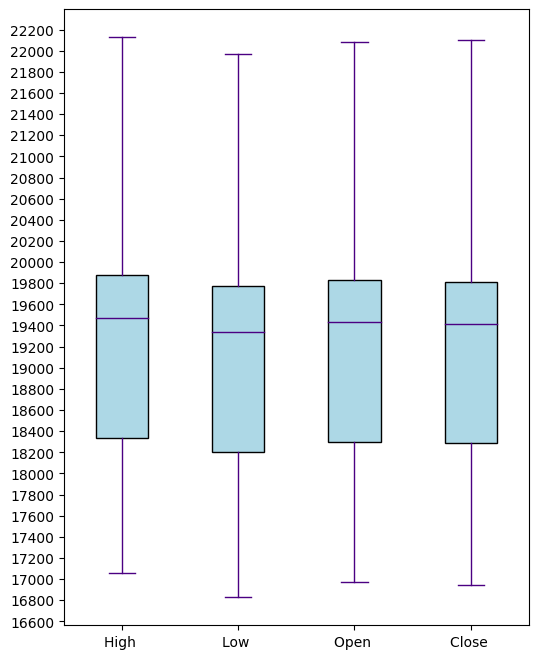

In [ ]:
nif[['High ', 'Low ',  'Open ', 'Close ']].plot(kind='box', color='Indigo',patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.gca().yaxis.set_major_locator(MultipleLocator(200))
plt.show()

In [ ]:
fig=go.Figure()
fig.add_trace(go.Candlestick(
    x=niftyit['Date'],
    open=niftyit['Open'],
    low=niftyit['Low'],
    high=niftyit['High'],
    close=niftyit['Close'],
    name='Low Price',
    increasing=dict(line=dict(color='green')),
    decreasing=dict(line=dict(color='red'))
))
fig.update_layout(
    title="Candlestick Chart",
    yaxis_title="Value",
    xaxis_title="Date",
    showlegend=True,
    plot_bgcolor='#e2baff',
    xaxis_rangeslider_visible=True
)

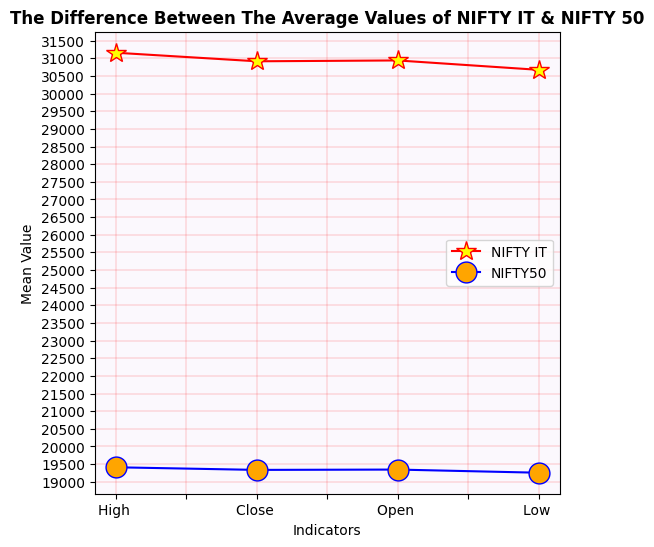

In [ ]:
mean1=niftyit[['High', 'Close', 'Open', 'Low']].mean()
plt.rcParams['figure.figsize']=(6,6)
ax=plt.axes()
ax.set_facecolor("#fbf8fd")
mean1.plot(color="RED" ,marker="*" , markersize=15, markerfacecolor="yellow", label="NIFTY IT")
mean.plot(color="blue" ,marker="o" , markersize=15, markerfacecolor="orange", label="NIFTY50")
plt.grid(True, alpha= 0.5, color="red", linewidth=0.3)
plt.gca().yaxis.set_major_locator(MultipleLocator(500))
plt.legend(loc="center right")
plt.xlabel("Indicators")
plt.ylabel("Mean Value")
plt.title("The Difference Between The Average Values of NIFTY IT & NIFTY 50", fontweight='semibold')
plt.show()

In [ ]:
print("\nMean of NIFTY IT Index")
mean1.to_frame()


Mean of NIFTY IT Index


,0
High,31159.160421
Close,30916.247419
Open,30940.293212
Low,30674.196558


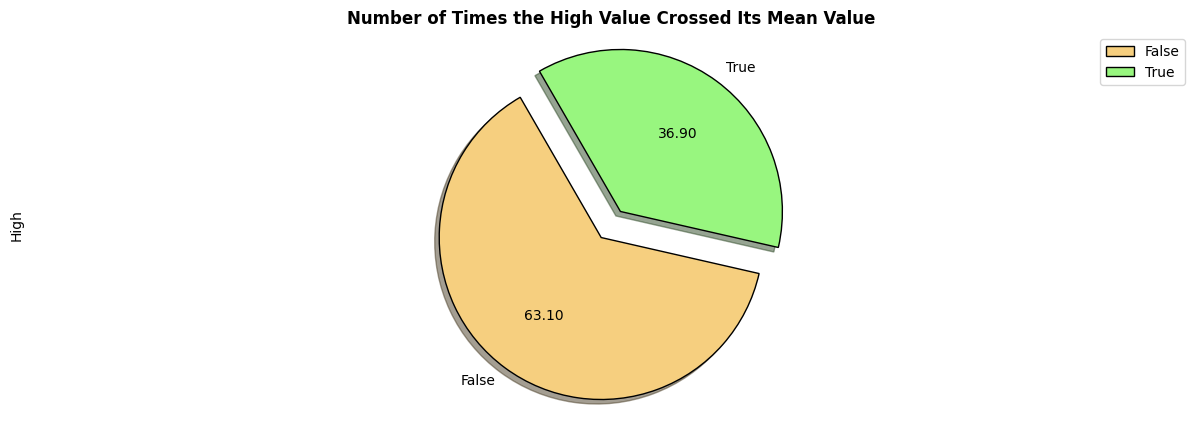

In [ ]:
plt.rcParams['figure.figsize']=(15,5)
means=(niftyit['High']>niftyit['High'].mean()).value_counts()
means.plot(kind="pie",autopct='%.2f', wedgeprops={'edgecolor':"black"}, startangle=120,explode=[0.1,0.1], shadow=True , colors=["#f6cf7f","#98f67f"])
plt.axis("equal")
plt.legend(loc='upper right')
plt.title("Number of Times the High Value Crossed Its Mean Value", fontweight="bold")
plt.show()

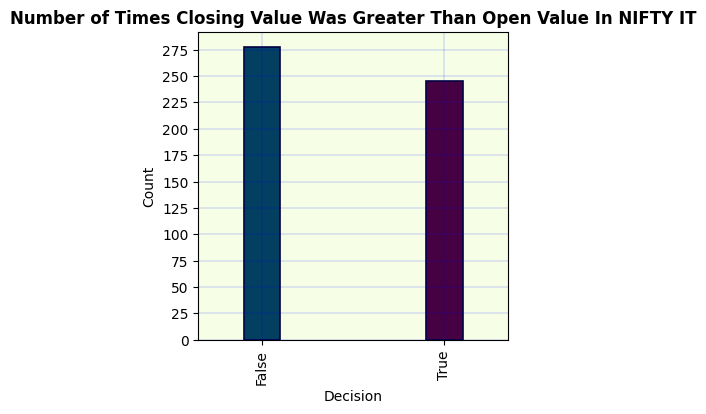

In [ ]:
plt.rcParams['figure.figsize']=(4,4)
ax=plt.axes()
ax.set_facecolor("#f6ffe6")
(niftyit['Close']>niftyit['Open']).value_counts().plot(kind='bar', color=['#023f60','#450141'], linewidth=1.2, edgecolor='#010145',width=0.2)
plt.ylabel("Count")
plt.xlabel("Decision")
plt.title("Number of Times Closing Value Was Greater Than Open Value In NIFTY IT", fontweight="semibold")
plt.gca().yaxis.set_major_locator(MultipleLocator(25))
plt.grid(True, alpha= 0.5, color="blue", linewidth=0.3)
plt.show()

In [ ]:
niftyit1=niftyit[niftyit['Date']>'2023-02-08']
niftyit1
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=nif['Date '],
    y=nif['Low '],
    name='NIFTY 50 HIGH PRICE',
    line=dict(color='#455429'),
    opacity=0.8
))
fig.add_trace(go.Scatter(
    x=niftyit1['Date'],
    y=niftyit1['Low'],
    name='NIFTY IT HIGH PRICE',
    line=dict(color='RED'),
    opacity=0.8
))
fig.update_layout(
    title="HIGH VALUE OF NIFTY 50 V/S NIFTY IT",
    yaxis_title="Value",
    showlegend=True,
    plot_bgcolor='#fee9f5'
)
fig.add_shape(
    type='rect',
    x0='2023-04-12',
    y0=16000,
    x1='2023-04-27',
    y1=38500,
    fillcolor="red",
    opacity=0.4,
)
fig.add_annotation(
    x='2023-04-28',
    y=26000,
    text="NIFTY_IT HITS IT'S LOWEST POINT & WAS MOST PROXIMATE WITH NIFTY 50",
    showarrow=True,
    arrowhead=6,
    ax=300,
    ay=10
)

In [ ]:
infy=pd.read_csv(r"/Quote-Equity-INFY-EQ-01-01-2023-to-01-01-2024.csv")
wip=pd.read_csv(r"/Quote-Equity-WIPRO-EQ-01-01-2023-to-01-01-2024.csv")
tcs=pd.read_csv(r"/Quote-Equity-TCS-EQ-01-01-2023-to-01-01-2024.csv")
infy['Date ']=pd.to_datetime(infy['Date '])
wip['Date ']=pd.to_datetime(wip['Date '])
tcs['Date ']=pd.to_datetime(tcs['Date '])
tcs

,Date,series,OPEN,HIGH,LOW,PREV. CLOSE,ltp,close,vwap,52W H,52W L,VOLUME,VALUE,No of trades
0,2024-01-01,EQ,"3,790.00","3,832.00","3,773.00","3,793.40","3,803.00","3,811.10","3,804.27","3,929.00","3,070.25","8,25,907","3,14,19,74,600.85","94,008"
1,2023-12-29,EQ,"3,792.00","3,822.60","3,765.40","3,799.90","3,800.00","3,793.40","3,796.92","3,929.00","3,070.25","15,74,996","5,98,01,29,693.80","1,31,434"
2,2023-12-28,EQ,"3,824.00","3,838.00","3,792.10","3,811.20","3,796.15","3,799.90","3,811.22","3,929.00","3,070.25","16,82,889","6,41,38,55,833.10","1,33,761"
3,2023-12-27,EQ,"3,799.00","3,818.20","3,768.00","3,795.55","3,808.00","3,811.20","3,792.62","3,929.00","3,070.25","12,93,976","4,90,75,56,179.85","1,35,647"
4,2023-12-26,EQ,"3,819.85","3,834.00","3,790.15","3,824.00","3,798.10","3,795.55","3,806.25","3,929.00","3,070.25","12,85,231","4,89,19,12,408.60","1,05,834"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,2023-01-06,EQ,"3,300.00","3,301.55","3,200.00","3,311.10","3,213.90","3,211.55","3,239.59","4,043.00","2,926.10","24,88,376","8,06,13,09,460.35","1,77,937"
243,2023-01-05,EQ,"3,330.20","3,337.30","3,281.95","3,314.65","3,302.65","3,311.10","3,311.44","4,043.00","2,926.10","18,26,057","6,04,68,82,556.65","1,28,658"
244,2023-01-04,EQ,"3,306.70","3,327.35","3,286.20","3,311.35","3,313.10","3,314.65","3,306.45","4,043.00","2,926.10","12,31,668","4,07,24,43,029.75","76,844"
245,2023-01-03,EQ,"3,252.00","3,320.00","3,245.30","3,261.45","3,312.00","3,311.35","3,300.29","4,043.00","2,926.10","12,45,178","4,10,94,51,969.85","78,401"


In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=wip['Date '],
    y=wip['vwap '],
    name='WIPRO',
    line=dict(color='magenta'),
    opacity=0.8
))
fig.add_trace(go.Scatter(
    x=infy['Date '],
    y=infy['vwap '],
    name='INFOSYS',
    line=dict(color='indigo'),
    opacity=0.8
))

fig.add_trace(go.Scatter(
    x=tcs['Date '],
    y=tcs['vwap '],
    name='TCS',
    line=dict(color='teal'),
    opacity=0.8
))
fig.update_layout(
    title="VWAP(Volume Weight Average Price)",
    yaxis_title="VWAP",
    showlegend=True,
    plot_bgcolor='lightgreen'
)
fig.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
tcs


,Date,series,OPEN,HIGH,LOW,PREV. CLOSE,ltp,close,vwap,52W H,52W L,VOLUME,VALUE,No of trades
0,2024-01-01,EQ,"3,790.00","3,832.00","3,773.00","3,793.40","3,803.00","3,811.10","3,804.27","3,929.00","3,070.25","8,25,907","3,14,19,74,600.85","94,008"
1,2023-12-29,EQ,"3,792.00","3,822.60","3,765.40","3,799.90","3,800.00","3,793.40","3,796.92","3,929.00","3,070.25","15,74,996","5,98,01,29,693.80","1,31,434"
2,2023-12-28,EQ,"3,824.00","3,838.00","3,792.10","3,811.20","3,796.15","3,799.90","3,811.22","3,929.00","3,070.25","16,82,889","6,41,38,55,833.10","1,33,761"
3,2023-12-27,EQ,"3,799.00","3,818.20","3,768.00","3,795.55","3,808.00","3,811.20","3,792.62","3,929.00","3,070.25","12,93,976","4,90,75,56,179.85","1,35,647"
4,2023-12-26,EQ,"3,819.85","3,834.00","3,790.15","3,824.00","3,798.10","3,795.55","3,806.25","3,929.00","3,070.25","12,85,231","4,89,19,12,408.60","1,05,834"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,2023-01-06,EQ,"3,300.00","3,301.55","3,200.00","3,311.10","3,213.90","3,211.55","3,239.59","4,043.00","2,926.10","24,88,376","8,06,13,09,460.35","1,77,937"
243,2023-01-05,EQ,"3,330.20","3,337.30","3,281.95","3,314.65","3,302.65","3,311.10","3,311.44","4,043.00","2,926.10","18,26,057","6,04,68,82,556.65","1,28,658"
244,2023-01-04,EQ,"3,306.70","3,327.35","3,286.20","3,311.35","3,313.10","3,314.65","3,306.45","4,043.00","2,926.10","12,31,668","4,07,24,43,029.75","76,844"
245,2023-01-03,EQ,"3,252.00","3,320.00","3,245.30","3,261.45","3,312.00","3,311.35","3,300.29","4,043.00","2,926.10","12,45,178","4,10,94,51,969.85","78,401"


In [ ]:
data=pd.read_csv(r"/TCS.NS.csv")
data

,Date,Open,High,Low,Close,Adj Close,Volume
0,2022-02-08,3791.550049,3799.699951,3721.000000,3743.449951,3563.721436,2946443
1,2022-02-09,3750.000000,3777.949951,3746.100098,3760.550049,3580.000488,1638721
2,2022-02-10,3789.800049,3789.800049,3758.000000,3770.350098,3589.329834,2112459
3,2022-02-11,3752.500000,3752.500000,3690.000000,3694.949951,3517.549805,3851488
4,2022-02-14,3724.000000,3793.250000,3710.000000,3733.750000,3554.487061,5951745
...,...,...,...,...,...,...,...
489,2024-02-01,3820.000000,3904.899902,3805.050049,3854.149902,3854.149902,2363107
490,2024-02-02,3875.050049,3984.399902,3872.000000,3966.300049,3966.300049,2826510
491,2024-02-05,3983.000000,4022.000000,3962.100098,3973.300049,3973.300049,1691523
492,2024-02-06,3997.000000,4149.899902,3990.000000,4136.000000,4136.000000,4474396


Epoch 1/50
13/13 [==============================] - 7s 5ms/step - loss: 0.1023
Epoch 2/50
13/13 [==============================] - 0s 4ms/step - loss: 0.0694
Epoch 3/50
13/13 [==============================] - 0s 4ms/step - loss: 0.0379
Epoch 4/50
13/13 [==============================] - 0s 5ms/step - loss: 0.0183
Epoch 5/50
13/13 [==============================] - 0s 3ms/step - loss: 0.0144
Epoch 6/50
13/13 [==============================] - 0s 4ms/step - loss: 0.0123
Epoch 7/50
13/13 [==============================] - 0s 4ms/step - loss: 0.0115
Epoch 8/50
13/13 [==============================] - 0s 4ms/step - loss: 0.0105
Epoch 9/50
13/13 [==============================] - 0s 4ms/step - loss: 0.0080
Epoch 10/50
13/13 [==============================] - 0s 4ms/step - loss: 0.0067
Epoch 11/50
13/13 [==============================] - 0s 4ms/step - loss: 0.0061
Epoch 12/50
13/13 [==============================] - 0s 4ms/step - loss: 0.0046
Epoch 13/50
13/13 [==============================

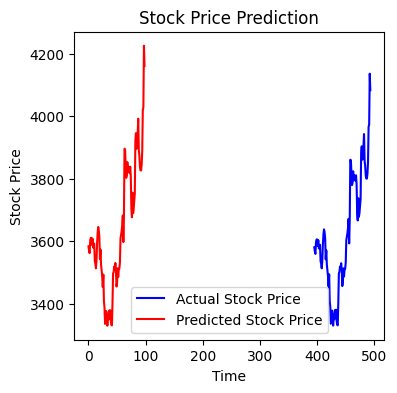

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data['Close'].values.reshape(-1, 1))

train_size = int(len(scaled_data) * 0.8)
test_size = len(scaled_data) - train_size
train_data, test_data = scaled_data[0:train_size, :], scaled_data[train_size:len(scaled_data), :]

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(train_data.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(train_data, train_data, epochs=50, batch_size=32)

test_predict = model.predict(test_data)
test_predict = scaler.inverse_transform(test_predict)
plt.plot(data['Close'][train_size:], color='blue', label='Actual Stock Price')
plt.plot(test_predict, color='red', label='Predicted Stock Price')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()